
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

In [14]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt

def SolucionPDE(f_func, a_val, b_val, ua, ub, N):
#Resuelve -u'' = f(x) en el dominio [a_val, b_val] con u(a)=ua, u(b)=ub.

    h = (b_val - a_val) / (N - 1)

    # pasos
    xi = np.zeros(N, float)
    for i in range(0, N):
        xi[i] = a_val + i * h

    # Matriz A
    A = np.zeros((N, N), float)
    for i in range(1, N):
        A[i-1, i-1] = A[i-1, i-1] + 1/h
        A[i-1, i] = A[i-1, i] - 1/h
        A[i, i-1] = A[i-1, i]
        A[i, i] = A[i, i] + 1/h

    # Guardo la matriz original para descontar las condiciones de frontera en 'b'
    A_orig = np.copy(A)

    # condiciones iniciales
    A[0, :] = 0; A[:, 0] = 0; A[0, 0] = 1
    A[N-1, :] = 0; A[:, N-1] = 0; A[N-1, N-1] = 1

    # phi(x)
    def lin1(x, x1, x2):
        return (x - x1) / (x2 - x1)

    def lin2(x, x1, x2):
        return (x2 - x) / (x2 - x1)

    # integrales para bi elementoss usando quad
    def int1(min_val, max_val):
        return integrate.quad(lambda x: f_func(x) * lin1(x, min_val, max_val), min_val, max_val)[0]

    def int2(min_val, max_val):
        return integrate.quad(lambda x: f_func(x) * lin2(x, min_val, max_val), min_val, max_val)[0]

    # Matriz B
    b = np.zeros(N, float)

    for i in range(1, N):
        b[i-1] = b[i-1] + int2(xi[i-1], xi[i])
        b[i] = b[i] + int1(xi[i-1], xi[i])

    # Aplicar condiciones de frontera al vector b
    for i in range(1, N-1):
        b[i] = b[i] - A_orig[i, 0] * ua - A_orig[i, N-1] * ub

    # COndiciones inciiales en el vector b
    b[0] = ua
    b[N-1] = ub

    # Resuelvo el sistema usando eliminacion gaussiana
    sol = np.linalg.solve(A, b)

    return xi, sol

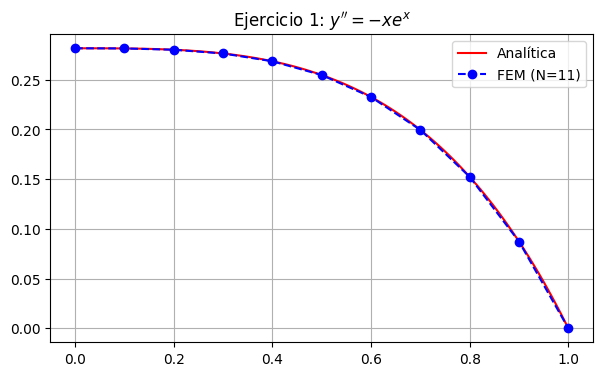

In [17]:
# Parámetros Ejercicio 1
N_elems = 11  # Equivalente a N=11 nodos (10 elementos)
f_ej1 = lambda x: x * np.exp(x)
ua_ej1 = 3 - np.e
ub_ej1 = 0

# Solución Analítica
y_analitica_ej1 = lambda x: np.exp(x)*(2 - x) - x + 1 - np.e

# Solución FEM usando el script general del punto punto anterior
x_ej1, sol_ej1 = SolucionPDE(f_ej1, 0, 1, ua_ej1, ub_ej1, N_elems)

# INterpolacion lineal
x_nuevo1 = np.linspace(0, 1, 100)

plt.figure(figsize=(7, 4))
plt.plot(x_nuevo1, y_analitica_ej1(x_nuevo1), 'r-', label='Analítica')
plt.plot(x_ej1, sol_ej1, 'bo--', label=f'FEM (N={N_elems})')
plt.title("Ejercicio 1: $y'' = -xe^x$")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3188/1449790051.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Ejercicio 2: $-U'' = \sin(\pi x)$")


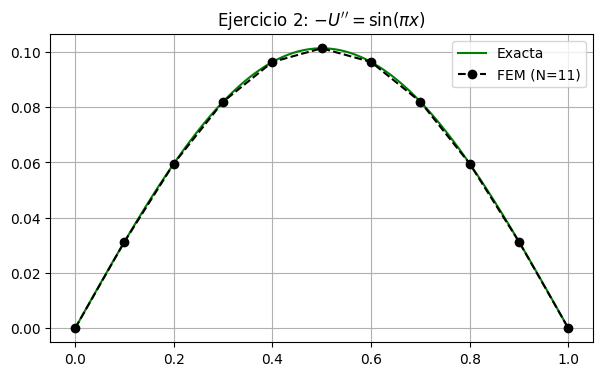

In [18]:
# Parámetros Ejercicio 2
f_ej2 = lambda x: np.sin(np.pi * x)
ua_ej2 = 0
ub_ej2 = 0

# Solución Analítica exacta
u_analitica_ej2 = lambda x: (1 / np.pi**2) * np.sin(np.pi * x)

# Solución FEM usando el script general
x_ej2, sol_ej2 = SolucionPDE(f_ej2, 0, 1, ua_ej2, ub_ej2, N_elems)

# INterpolacion lineal
x_nuevo2 = np.linspace(0, 1, 100)

plt.figure(figsize=(7, 4))
plt.plot(x_nuevo2, u_analitica_ej2(x_nuevo2), 'g-', label='Exacta')
plt.plot(x_ej2, sol_ej2, 'ko--', label=f'FEM (N={N_elems})')
plt.title("Ejercicio 2: $-U'' = \sin(\pi x)$")
plt.legend()
plt.grid(True)
plt.show()